In [1]:
pip install inference-sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.11.15
    Uninstalling aiohttp-3.11.15:
      Successfully uninstalled aiohttp-3.11.15


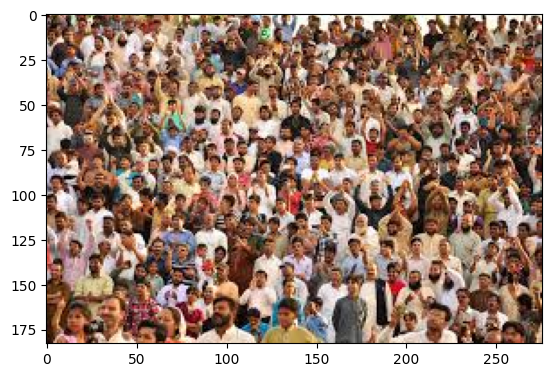

In [26]:
from inference_sdk import InferenceHTTPClient
import matplotlib.pyplot as plt


CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="poXcqijmjIAjyhnYTqob"
)
your_image = '/content/images.jpg'
plt.imshow(plt.imread(your_image))

result = CLIENT.infer(your_image, model_id="crowd-density-estimation/3")

In [27]:
print(result)

{'inference_id': 'eeaef43a-8e9a-4969-8df8-73a9405da4df', 'time': 0.02960452399929636, 'image': {'width': 276, 'height': 183}, 'predictions': [{'x': 133.5, 'y': 167.5, 'width': 11.0, 'height': 13.0, 'confidence': 0.8084512948989868, 'class': 'people', 'class_id': 0, 'detection_id': '7ee61f56-1c25-40f3-b9c6-4aa5e0dba9ca'}, {'x': 75.5, 'y': 132.0, 'width': 9.0, 'height': 8.0, 'confidence': 0.803786039352417, 'class': 'people', 'class_id': 0, 'detection_id': '32e3fa12-a8a7-4d77-836c-91851a4f80b8'}, {'x': 216.5, 'y': 142.5, 'width': 9.0, 'height': 9.0, 'confidence': 0.8036943674087524, 'class': 'people', 'class_id': 0, 'detection_id': 'd45ae8e6-9de4-4aad-ac80-1d619dc8c522'}, {'x': 119.0, 'y': 147.5, 'width': 8.0, 'height': 9.0, 'confidence': 0.8031830191612244, 'class': 'people', 'class_id': 0, 'detection_id': '7b2061f5-c7e3-4bf1-82b3-d39150cb9839'}, {'x': 17.0, 'y': 168.5, 'width': 12.0, 'height': 13.0, 'confidence': 0.802294135093689, 'class': 'people', 'class_id': 0, 'detection_id': '4d1

In [28]:
print(len(result['predictions']))

300


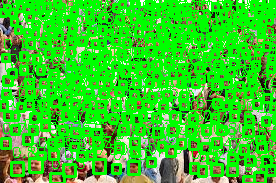

In [29]:
import cv2
from google.colab.patches import cv2_imshow

# Load image
img = cv2.imread("images.jpg")

# Draw predictions
for pred in result["predictions"]:
    x, y, w, h = pred["x"], pred["y"], pred["width"], pred["height"]
    confidence = pred["confidence"]

    # Calculate top-left and bottom-right points
    x1 = int(x - w / 2)
    y1 = int(y - h / 2)
    x2 = int(x + w / 2)
    y2 = int(y + h / 2)

    # Draw rectangle and label
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img, f'{confidence:.2f}', (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# Show image
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()